In [1]:
import pandas as pd

In [2]:
# Load dataset
df = pd.read_csv("online_retail_II.csv", encoding="latin1")

In [3]:
# Basic information
print("Shape:", df.shape)

Shape: (541910, 8)


In [4]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [5]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64


### Step 2: Clean the Data

In [7]:
# Make a copy
cohort_df = df.copy()

In [8]:
# 1. Remove transactions without Customer ID
cohort_df = cohort_df.dropna(subset=["Customer ID"])

In [9]:
# 2. Remove cancelled invoices
cohort_df = cohort_df[
    ~cohort_df["Invoice"].astype(str).str.startswith("C")
]

In [10]:
# 3. Keep only positive quantities
cohort_df = cohort_df[cohort_df["Quantity"] > 0]

In [11]:
# 4. Convert InvoiceDate to datetime
cohort_df["InvoiceDate"] = pd.to_datetime(cohort_df["InvoiceDate"])

C:\Users\Bikash Mahato\AppData\Local\Temp\ipykernel_33996\892072221.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cohort_df["InvoiceDate"] = pd.to_datetime(cohort_df["InvoiceDate"])


In [12]:
# 5. Make Customer ID an integer
cohort_df["Customer ID"] = cohort_df["Customer ID"].astype(int)

In [13]:
print("Original rows:", len(df))
print("Cleaned rows:", len(cohort_df))

Original rows: 541910
Cleaned rows: 397925


In [14]:
print("\nMissing Customer IDs:")
print(cohort_df["Customer ID"].isna().sum())

print("\nData types:")
print(cohort_df[["Customer ID", "InvoiceDate"]].dtypes)

print("\nDate range:")
print(cohort_df["InvoiceDate"].min(), "to", cohort_df["InvoiceDate"].max())


Missing Customer IDs:
0

Data types:
Customer ID             int64
InvoiceDate    datetime64[us]
dtype: object

Date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00


### Step 3: Define the Cohort

In [15]:
# Find each customer's first purchase date
first_purchase = (
    cohort_df.groupby("Customer ID")["InvoiceDate"]
    .min()
    .reset_index()
)

In [16]:
# Rename for clarity
first_purchase.rename(
    columns={"InvoiceDate": "FirstPurchaseDate"},
    inplace=True
)

In [17]:
# Convert first purchase date to month
first_purchase["CohortMonth"] = (
    first_purchase["FirstPurchaseDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Show the result
print(first_purchase.head(10))

   Customer ID   FirstPurchaseDate CohortMonth
0        12346 2011-01-18 10:01:00  2011-01-01
1        12347 2010-12-07 14:57:00  2010-12-01
2        12348 2010-12-16 19:09:00  2010-12-01
3        12349 2011-11-21 09:51:00  2011-11-01
4        12350 2011-02-02 16:01:00  2011-02-01
5        12352 2011-02-16 12:33:00  2011-02-01
6        12353 2011-05-19 17:47:00  2011-05-01
7        12354 2011-04-21 13:11:00  2011-04-01
8        12355 2011-05-09 13:49:00  2011-05-01
9        12356 2011-01-18 09:50:00  2011-01-01


### Step 4: Attach Cohort Month to Every Transaction

In [18]:
# Merge each customer's cohort information
cohort_df = cohort_df.merge(
    first_purchase[["Customer ID", "CohortMonth"]],
    on="Customer ID",
    how="left"
)

In [19]:
# Create the transaction month
cohort_df["PurchaseMonth"] = (
    cohort_df["InvoiceDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [20]:
# Check the result
print(cohort_df[
    ["Customer ID", "InvoiceDate", "CohortMonth", "PurchaseMonth"]
].head(10))

   Customer ID         InvoiceDate CohortMonth PurchaseMonth
0        17850 2010-12-01 08:26:00  2010-12-01    2010-12-01
1        17850 2010-12-01 08:26:00  2010-12-01    2010-12-01
2        17850 2010-12-01 08:26:00  2010-12-01    2010-12-01
3        17850 2010-12-01 08:26:00  2010-12-01    2010-12-01
4        17850 2010-12-01 08:26:00  2010-12-01    2010-12-01
5        17850 2010-12-01 08:26:00  2010-12-01    2010-12-01
6        17850 2010-12-01 08:26:00  2010-12-01    2010-12-01
7        17850 2010-12-01 08:28:00  2010-12-01    2010-12-01
8        17850 2010-12-01 08:28:00  2010-12-01    2010-12-01
9        13047 2010-12-01 08:34:00  2010-12-01    2010-12-01


### Step 5: Calculate Months Since Cohort

In [21]:
# Calculate the number of months since the customer's cohort month
cohort_df["MonthsSinceCohort"] = (
    (cohort_df["PurchaseMonth"].dt.year - cohort_df["CohortMonth"].dt.year) * 12
    + (cohort_df["PurchaseMonth"].dt.month - cohort_df["CohortMonth"].dt.month)
)

In [22]:
# Check the result
print(
    cohort_df[
        ["Customer ID", "CohortMonth", "PurchaseMonth", "MonthsSinceCohort"]
    ].head(15)
)

    Customer ID CohortMonth PurchaseMonth  MonthsSinceCohort
0         17850  2010-12-01    2010-12-01                  0
1         17850  2010-12-01    2010-12-01                  0
2         17850  2010-12-01    2010-12-01                  0
3         17850  2010-12-01    2010-12-01                  0
4         17850  2010-12-01    2010-12-01                  0
5         17850  2010-12-01    2010-12-01                  0
6         17850  2010-12-01    2010-12-01                  0
7         17850  2010-12-01    2010-12-01                  0
8         17850  2010-12-01    2010-12-01                  0
9         13047  2010-12-01    2010-12-01                  0
10        13047  2010-12-01    2010-12-01                  0
11        13047  2010-12-01    2010-12-01                  0
12        13047  2010-12-01    2010-12-01                  0
13        13047  2010-12-01    2010-12-01                  0
14        13047  2010-12-01    2010-12-01                  0


### Step 6: Count Active Customers

In [23]:
# Count unique active customers for each cohort and month
cohort_counts = (
    cohort_df
    .groupby(["CohortMonth", "MonthsSinceCohort"])["Customer ID"]
    .nunique()
    .reset_index()
)

In [24]:
# Rename the column
cohort_counts.rename(
    columns={"Customer ID": "ActiveCustomers"},
    inplace=True
)

# Display the first rows
print(cohort_counts.head(20))

   CohortMonth  MonthsSinceCohort  ActiveCustomers
0   2010-12-01                  0              885
1   2010-12-01                  1              324
2   2010-12-01                  2              286
3   2010-12-01                  3              340
4   2010-12-01                  4              321
5   2010-12-01                  5              352
6   2010-12-01                  6              321
7   2010-12-01                  7              309
8   2010-12-01                  8              313
9   2010-12-01                  9              350
10  2010-12-01                 10              331
11  2010-12-01                 11              445
12  2010-12-01                 12              235
13  2011-01-01                  0              417
14  2011-01-01                  1               92
15  2011-01-01                  2              111
16  2011-01-01                  3               96
17  2011-01-01                  4              134
18  2011-01-01                 

### Step 7: Calculate Retention %

In [25]:
# Get the Month 0 customer count for each cohort
cohort_sizes = (
    cohort_counts[cohort_counts["MonthsSinceCohort"] == 0]
    [["CohortMonth", "ActiveCustomers"]]
    .rename(columns={"ActiveCustomers": "CohortSize"})
)

# Add cohort size to every row
cohort_counts = cohort_counts.merge(
    cohort_sizes,
    on="CohortMonth",
    how="left"
)

# Calculate retention percentage
cohort_counts["RetentionRate"] = (
    cohort_counts["ActiveCustomers"]
    / cohort_counts["CohortSize"]
    * 100
)

# Display results
print(cohort_counts.head(20))

   CohortMonth  MonthsSinceCohort  ActiveCustomers  CohortSize  RetentionRate
0   2010-12-01                  0              885         885     100.000000
1   2010-12-01                  1              324         885      36.610169
2   2010-12-01                  2              286         885      32.316384
3   2010-12-01                  3              340         885      38.418079
4   2010-12-01                  4              321         885      36.271186
5   2010-12-01                  5              352         885      39.774011
6   2010-12-01                  6              321         885      36.271186
7   2010-12-01                  7              309         885      34.915254
8   2010-12-01                  8              313         885      35.367232
9   2010-12-01                  9              350         885      39.548023
10  2010-12-01                 10              331         885      37.401130
11  2010-12-01                 11              445         885  

### Step 8: Create the Cohort Retention Matrix

In [26]:
# Create the cohort retention matrix
retention_matrix = cohort_counts.pivot(
    index="CohortMonth",
    columns="MonthsSinceCohort",
    values="RetentionRate"
)

# Rename columns
retention_matrix.columns = [
    f"Month {int(col)}" for col in retention_matrix.columns
]

# Display the matrix
display(retention_matrix.round(2))

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11,Month 12
CohortMonth,,,,,,,,,,,,,
2010-12-01,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28,26.55
2011-01-01,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,11.75,NaN
2011-02-01,100.0,18.68,18.68,28.42,27.11,24.74,25.26,27.89,24.74,30.53,6.84,NaN,NaN
2011-03-01,100.0,15.04,25.22,19.91,22.35,16.81,26.77,23.01,27.88,8.63,NaN,NaN,NaN
2011-04-01,100.0,21.33,20.33,21.00,19.67,22.67,21.67,26.00,7.33,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.01,17.25,17.25,20.77,23.24,26.41,9.51,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.36,15.70,26.45,23.14,33.47,9.50,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,18.09,20.74,22.34,27.13,11.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,20.71,24.85,24.26,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 9: Create the Retention Heatmap

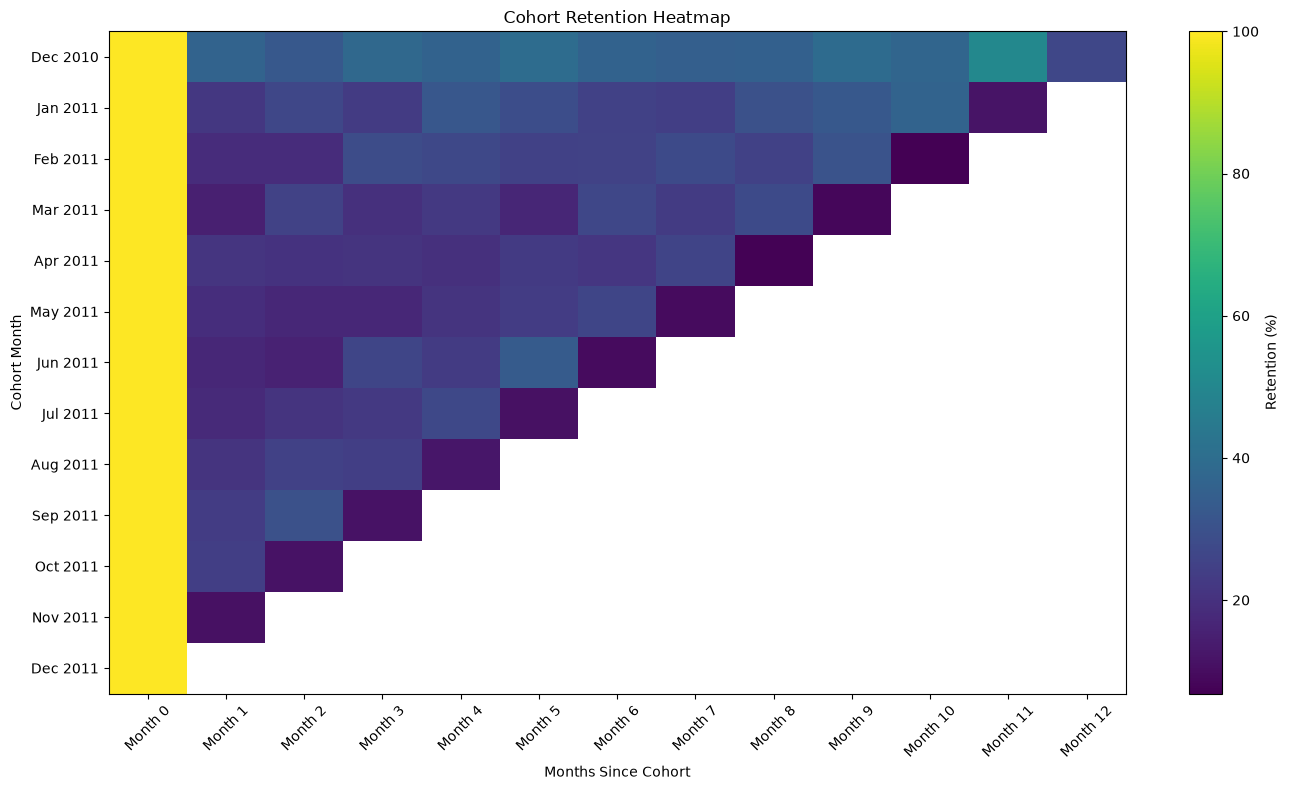

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plt.imshow(
    retention_matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Retention (%)")

plt.title("Cohort Retention Heatmap")
plt.xlabel("Months Since Cohort")
plt.ylabel("Cohort Month")

# X-axis labels
plt.xticks(
    range(len(retention_matrix.columns)),
    retention_matrix.columns,
    rotation=45
)

# Y-axis labels
plt.yticks(
    range(len(retention_matrix.index)),
    retention_matrix.index.strftime("%b %Y")
)

plt.tight_layout()
plt.show()

### Step 10: Extract Business Insights

In [28]:
# Month 1 retention
month_1 = retention_matrix["Month 1"].dropna()

# Month 3 retention
month_3 = retention_matrix["Month 3"].dropna()

# Month 6 retention
month_6 = retention_matrix["Month 6"].dropna()

print("Average Month 1 Retention:", round(month_1.mean(), 2), "%")
print("Average Month 3 Retention:", round(month_3.mean(), 2), "%")
print("Average Month 6 Retention:", round(month_6.mean(), 2), "%")

print("\nNumber of cohorts:")
print("Month 1:", len(month_1))
print("Month 3:", len(month_3))
print("Month 6:", len(month_6))

Average Month 1 Retention: 20.62 %
Average Month 3 Retention: 23.24 %
Average Month 6 Retention: 24.37 %

Number of cohorts:
Month 1: 12
Month 3: 10
Month 6: 7


In [29]:
print("Highest Month 1 retention:")
print(month_1.idxmax(), "→", round(month_1.max(), 2), "%")

print("\nLowest Month 1 retention:")
print(month_1.idxmin(), "→", round(month_1.min(), 2), "%")

print("\nHighest Month 3 retention:")
print(month_3.idxmax(), "→", round(month_3.max(), 2), "%")

print("\nLowest Month 3 retention:")
print(month_3.idxmin(), "→", round(month_3.min(), 2), "%")

Highest Month 1 retention:
2010-12-01 00:00:00 → 36.61 %

Lowest Month 1 retention:
2011-11-01 00:00:00 → 11.11 %

Highest Month 3 retention:
2010-12-01 00:00:00 → 38.42 %

Lowest Month 3 retention:
2011-09-01 00:00:00 → 11.37 %


In [30]:
import openpyxl

print("openpyxl version:", openpyxl.__version__)

openpyxl version: 3.1.5


In [31]:
import pandas as pd

output_file = "Day_22_Cohort_Retention_Analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # 1. Raw Data
    df.to_excel(
        writer,
        sheet_name="Raw Data",
        index=False
    )

    # 2. Cleaned Data
    cohort_df.to_excel(
        writer,
        sheet_name="Cleaned Data",
        index=False
    )

    # 3. Cohort Analysis
    cohort_counts.to_excel(
        writer,
        sheet_name="Cohort Analysis",
        index=False
    )

    # 4. Retention Matrix
    retention_matrix.to_excel(
        writer,
        sheet_name="Retention Matrix"
    )

    # 5. Insights
    insights = pd.DataFrame({
        "Metric": [
            "Average Month 1 Retention",
            "Average Month 3 Retention",
            "Average Month 6 Retention",
            "Highest Month 1 Retention Cohort",
            "Lowest Month 1 Retention Cohort",
            "Highest Month 3 Retention Cohort",
            "Lowest Month 3 Retention Cohort"
        ],
        "Value": [
            f"{month_1.mean():.2f}%",
            f"{month_3.mean():.2f}%",
            f"{month_6.mean():.2f}%",
            f"{month_1.idxmax().strftime('%b %Y')} ({month_1.max():.2f}%)",
            f"{month_1.idxmin().strftime('%b %Y')} ({month_1.min():.2f}%)",
            f"{month_3.idxmax().strftime('%b %Y')} ({month_3.max():.2f}%)",
            f"{month_3.idxmin().strftime('%b %Y')} ({month_3.min():.2f}%)"
        ]
    })

    insights.to_excel(
        writer,
        sheet_name="Insights",
        index=False
    )

print(f"Excel workbook created: {output_file}")

Excel workbook created: Day_22_Cohort_Retention_Analysis.xlsx


### Step 11: Format the Excel Workbook

In [32]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.formatting.rule import ColorScaleRule

file_path = "Day_22_Cohort_Retention_Analysis.xlsx"

# Load workbook
wb = load_workbook(file_path)

# -----------------------------
# Format Retention Matrix
# -----------------------------
ws = wb["Retention Matrix"]

# Header formatting
for cell in ws[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center")

# Format percentages
for row in ws.iter_rows(min_row=2, min_col=2):
    for cell in row:
        if isinstance(cell.value, (int, float)):
            cell.number_format = "0.00%"

# Add heatmap color scale
ws.conditional_formatting.add(
    f"B2:{ws.cell(ws.max_row, ws.max_column).coordinate}",
    ColorScaleRule(
        start_type="min",
        start_color="FFFFFF",
        mid_type="percentile",
        mid_value=50,
        mid_color="FFF2CC",
        end_type="max",
        end_color="63BE7B"
    )
)

# Freeze header
ws.freeze_panes = "B2"

# Adjust column widths
ws.column_dimensions["A"].width = 18

for col in range(2, ws.max_column + 1):
    ws.column_dimensions[
        ws.cell(row=1, column=col).column_letter
    ].width = 12

# Save
wb.save(file_path)

print("Retention Matrix formatted successfully.")

Retention Matrix formatted successfully.


### Step 12: Final Business Insights

In [33]:
# Display the key retention metrics

print("===== DAY 22: COHORT RETENTION INSIGHTS =====")

print(f"\nAverage Month 1 Retention: {month_1.mean():.2f}%")
print(f"Average Month 3 Retention: {month_3.mean():.2f}%")
print(f"Average Month 6 Retention: {month_6.mean():.2f}%")

print("\n----- Month 1 -----")
print(
    f"Highest: {month_1.idxmax().strftime('%b %Y')} "
    f"→ {month_1.max():.2f}%"
)
print(
    f"Lowest: {month_1.idxmin().strftime('%b %Y')} "
    f"→ {month_1.min():.2f}%"
)

print("\n----- Month 3 -----")
print(
    f"Highest: {month_3.idxmax().strftime('%b %Y')} "
    f"→ {month_3.max():.2f}%"
)
print(
    f"Lowest: {month_3.idxmin().strftime('%b %Y')} "
    f"→ {month_3.min():.2f}%"
)

print("\n----- Month 6 -----")
print(
    f"Highest: {month_6.idxmax().strftime('%b %Y')} "
    f"→ {month_6.max():.2f}%"
)
print(
    f"Lowest: {month_6.idxmin().strftime('%b %Y')} "
    f"→ {month_6.min():.2f}%"
)

===== DAY 22: COHORT RETENTION INSIGHTS =====

Average Month 1 Retention: 20.62%
Average Month 3 Retention: 23.24%
Average Month 6 Retention: 24.37%

----- Month 1 -----
Highest: Dec 2010 → 36.61%
Lowest: Nov 2011 → 11.11%

----- Month 3 -----
Highest: Dec 2010 → 38.42%
Lowest: Sep 2011 → 11.37%

----- Month 6 -----
Highest: Dec 2010 → 36.27%
Lowest: Jun 2011 → 9.50%


In [34]:
retention_matrix.to_csv("Day_22_Retention_Matrix.csv")

print("Retention matrix saved successfully.")

Retention matrix saved successfully.


In [35]:
display(retention_matrix.round(2))

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11,Month 12
CohortMonth,,,,,,,,,,,,,
2010-12-01,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28,26.55
2011-01-01,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,11.75,NaN
2011-02-01,100.0,18.68,18.68,28.42,27.11,24.74,25.26,27.89,24.74,30.53,6.84,NaN,NaN
2011-03-01,100.0,15.04,25.22,19.91,22.35,16.81,26.77,23.01,27.88,8.63,NaN,NaN,NaN
2011-04-01,100.0,21.33,20.33,21.00,19.67,22.67,21.67,26.00,7.33,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.01,17.25,17.25,20.77,23.24,26.41,9.51,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.36,15.70,26.45,23.14,33.47,9.50,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,18.09,20.74,22.34,27.13,11.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,20.71,24.85,24.26,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 13: Business Insights

1. Month 1 retention

Across the cohorts with a complete Month 1 observation, retention ranges from 11.11% to 36.61%.

Highest observed Month 1: December 2010 — 36.61%
Lowest observed Month 1: November 2011 — 11.11%

This means the percentage of customers returning one month after their first purchase varies substantially by cohort.

2. Month 3 retention

For cohorts with Month 3 data:

December 2010: 38.42%
January 2011: 23.02%
February 2011: 28.42%
March 2011: 19.91%
April 2011: 21.00%
May 2011: 17.25%
June 2011: 26.45%
July 2011: 22.34%
August 2011: 24.26%
September 2011: 11.37%

The December 2010 cohort has the highest observed Month 3 retention in this dataset at 38.42%.

3. Retention does not necessarily decrease every month

An important observation is that retention isn't strictly declining every month.

For example, the December 2010 cohort:

36.61% → 32.32% → 38.42% → 36.27% → 39.77%

This happens because customers can return at different times. Cohort retention measures activity in each month, not necessarily continuous monthly activity.

That's an important point to mention in an interview.

4. Later cohorts have fewer observable months

For example:

December 2010 has Month 0 through Month 12.
July 2011 has data only through Month 5.
December 2011 only has Month 0.

The NaN values therefore do not mean zero retention.

They mean:

There isn't enough historical data to calculate that cohort's retention for that month.

5. Long-term retention

The December 2010 cohort provides the longest observation window:

Month	Retention
Month 0	100.00%
Month 1	36.61%
Month 2	32.32%
Month 3	38.42%
Month 6	36.27%
Month 9	39.55%
Month 12	26.55%

So, among the December 2010 cohort, 26.55% of the original customers were active again in Month 12.